In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.inspection import permutation_importance

# Show all columns when printing
pd.set_option('display.max_columns', None)


In [2]:
target = pd.read_csv('src/data/training/processed/final_training_data.csv')
target['mix__sd_od_history_to_kyc_ratio'] = target['od__history_length_days'] / target['sd__age_since_first_kyc']
#target = target.drop(columns=['user_id', 'reference_date', 'default_date'])
target = target.loc[:, ~target.columns.str.startswith(('dn__', 'madrid__'))]

In [3]:
defref_diff = (
    (pd.to_datetime(target['default_date']).dt.year -
     pd.to_datetime(target['reference_date']).dt.year) * 12
    +
    (pd.to_datetime(target['default_date']).dt.month -
     pd.to_datetime(target['reference_date']).dt.month)
)

target['defref_diff'] = defref_diff

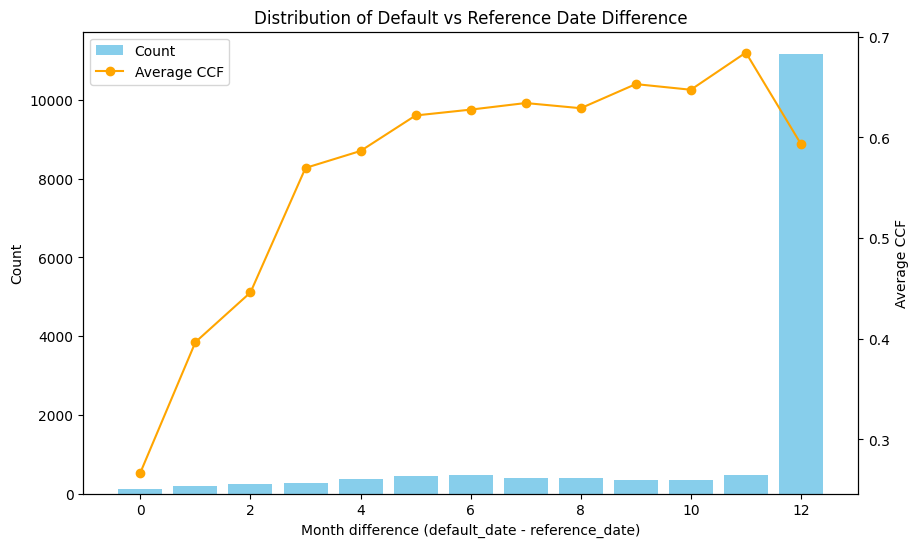

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# Example target dataframe: target['defref_diff'], target['ccf']

# Compute counts per month difference
counts = target['defref_diff'].value_counts().sort_index()

# Compute average CCF per month difference
avg_ccf = target.groupby('defref_diff')['t__ccf'].mean()

# Start plotting
fig, ax1 = plt.subplots(figsize=(10,6))

# Bar plot for counts
ax1.bar(counts.index, counts.values, label='Count', color = 'skyblue')
ax1.set_xlabel("Month difference (default_date - reference_date)")
ax1.set_ylabel("Count")
ax1.set_title("Distribution of Default vs Reference Date Difference")

# Secondary y-axis for avg CCF
ax2 = ax1.twinx()
ax2.plot(avg_ccf.index, avg_ccf.values, color='orange', marker='o', label='Average CCF')
ax2.set_ylabel("Average CCF")
ax2.tick_params(axis='y')

# Optional: add legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

ValueError: x and y must have same first dimension, but have shapes (107,) and (108,)

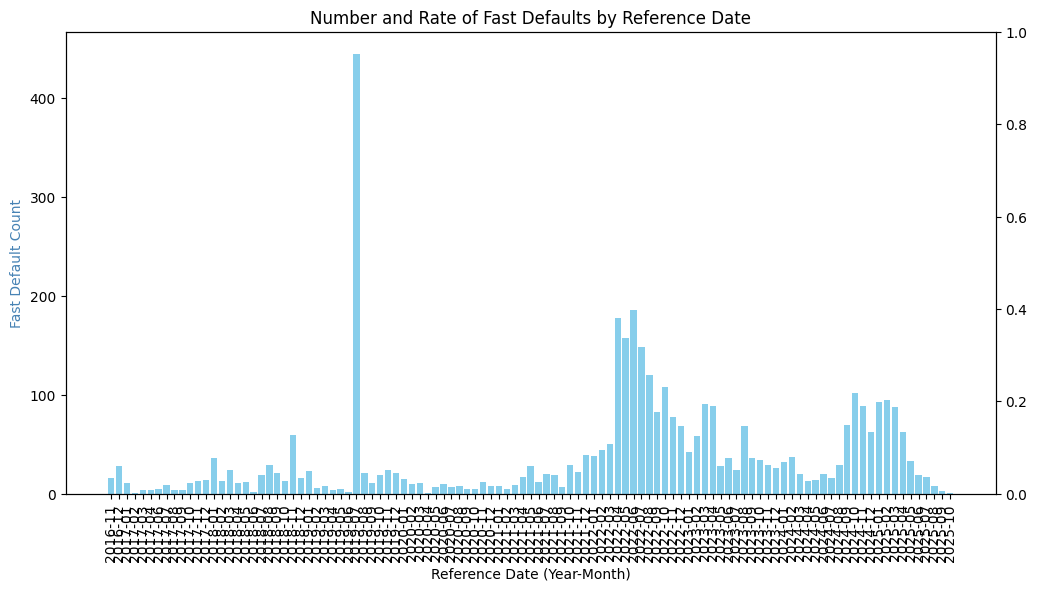

In [27]:
# 1. Ensure reference_date is datetime
target['reference_date'] = pd.to_datetime(target['reference_date'])

# 2. Define fast defaults:
# Option A: If fast default is defined by a threshold on defref_diff (e.g., default within <= 3 or 6 months)
fast_default_threshold = 11  # adjust threshold as needed
fast_defaults_df = target[
    (target['defref_diff'].notna())
    & (target['defref_diff'] <= fast_default_threshold)
]

# Option B: If you already have a boolean/binary column (e.g., 'is_fast_default')
# fast_defaults_df = target[target['is_fast_default'] == 1]

# 3. Aggregate counts by reference date (e.g., monthly)
fast_counts = fast_defaults_df.groupby(
    target['reference_date'].dt.to_period('M')
).size()
total_counts = target.groupby(
    target['reference_date'].dt.to_period('M')
).size()

# Calculate Fast Default Rate (%)
fast_rate = (fast_counts / total_counts) * 100

x_labels = fast_counts.index.astype(str)

# 4. Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Axis: Count of Fast Defaults
ax1.bar(
    x_labels, fast_counts.values, label='Fast Default Count', color='skyblue'
)
ax1.set_xlabel('Reference Date (Year-Month)')
ax1.set_ylabel('Fast Default Count', color='steelblue')
ax1.set_title('Number and Rate of Fast Defaults by Reference Date')
ax1.tick_params(axis='x', rotation=90)

# Secondary Axis: Fast Default Rate (%)
ax2 = ax1.twinx()
ax2.plot(
    x_labels,
    fast_rate.values,
    color='darkorange',
    marker='o',
    linewidth=2,
    label='Fast Default Rate (%)',
)
ax2.set_ylabel('Fast Default Rate (%)', color='darkorange')

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [5]:
# Basic stats
print(target['t__ccf'].describe())

# Check for missing values
print(target['t__ccf'].isna().sum())

# Check skewness and kurtosis
print(f"Skewness: {target['t__ccf'].skew()}")
print(f"Kurtosis: {target['t__ccf'].kurt()}")


count    15211.000000
mean         0.595126
std          0.459190
min          0.000000
25%          0.000000
50%          0.943730
75%          1.000000
max          1.000000
Name: t__ccf, dtype: float64
0
Skewness: -0.40120701881948334
Kurtosis: -1.7327465577772623


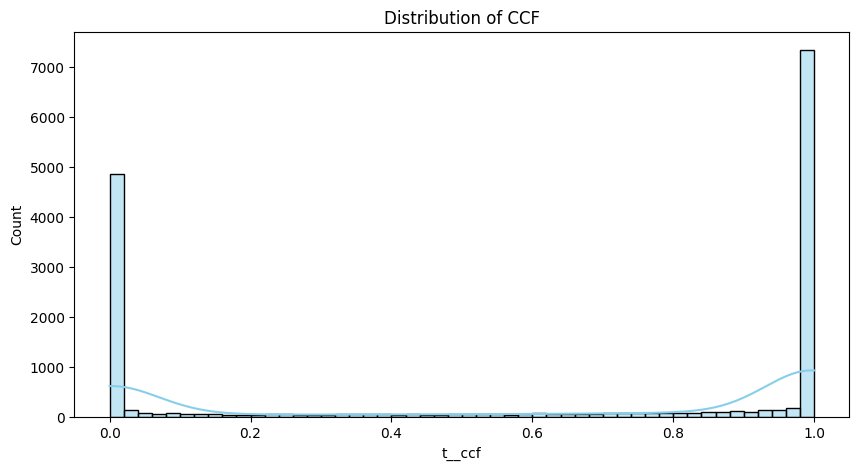

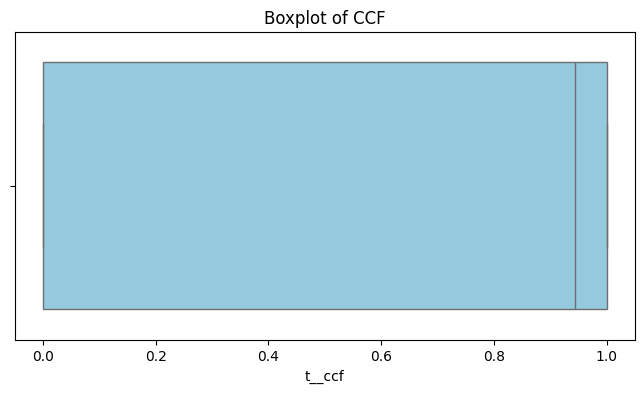

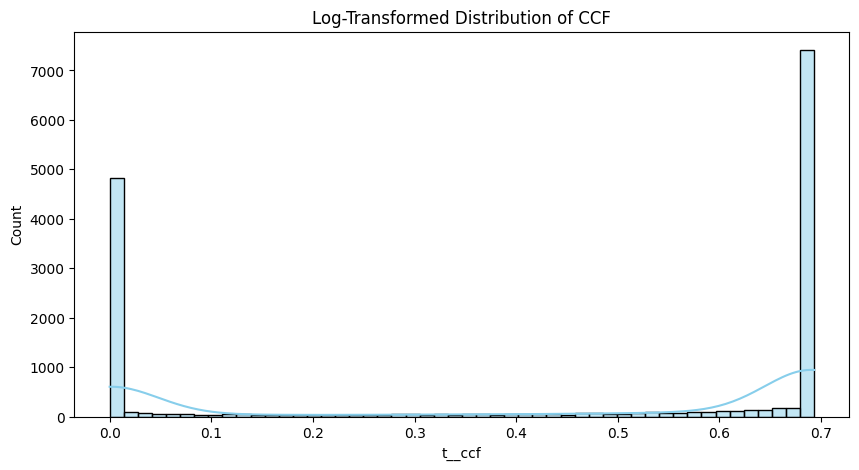

In [6]:
# Histogram + KDE
plt.figure(figsize=(10,5))
sns.histplot(target['t__ccf'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of CCF')
plt.show()

# Boxplot to detect outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=target['t__ccf'], color='skyblue')
plt.title('Boxplot of CCF')
plt.show()

# Optionally, check for log-normality
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(target['t__ccf']), bins=50, kde=True, color='skyblue')
plt.title('Log-Transformed Distribution of CCF')
plt.show()

In [7]:
# Basic stats
print(target['t__ccf'].describe())

# Check for missing values
print(target['t__ccf'].isna().sum())

# Check skewness and kurtosis
print(f"Skewness: {target['t__ccf'].skew()}")
print(f"Kurtosis: {target['t__ccf'].kurt()}")

count    15211.000000
mean         0.595126
std          0.459190
min          0.000000
25%          0.000000
50%          0.943730
75%          1.000000
max          1.000000
Name: t__ccf, dtype: float64
0
Skewness: -0.40120701881948334
Kurtosis: -1.7327465577772623


In [8]:
features = target.drop(columns=['t__ccf', 't__is_drawn', 'user_id', 'reference_date', 'default_date', 'defref_diff'])
target_ccf = target['t__ccf']

In [9]:
def plot_top_features(series, title):
    top = series.head(20).sort_values()
    plt.figure(figsize=(10,6))
    top.plot(kind='barh', color='skyblue')
    plt.title(title)
    plt.xlabel('Importance')
    plt.show()

In [17]:
# --- 1. Correlation ---
corr_ccf = features.corrwith(target_ccf).abs().sort_values(ascending=False)

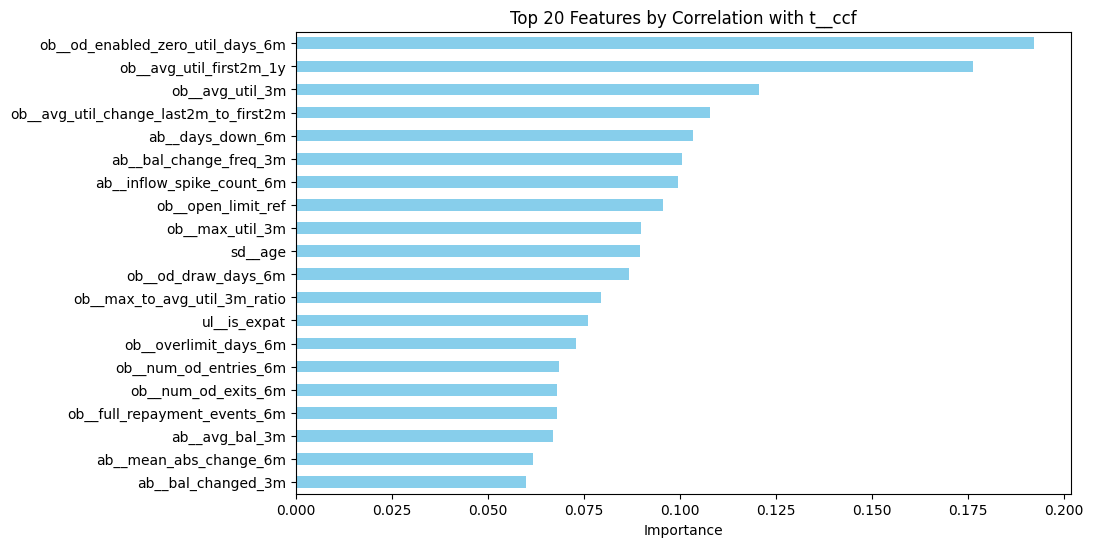

In [18]:
plot_top_features(corr_ccf, 'Top 20 Features by Correlation with t__ccf')

In [11]:
# --- 3. Random Forest Importance ---
rf_ccf = RandomForestRegressor(n_estimators=500, random_state=42)
rf_ccf.fit(features, target_ccf)
rf_ccf_imp = pd.Series(rf_ccf.feature_importances_, index=features.columns).sort_values(ascending=False)

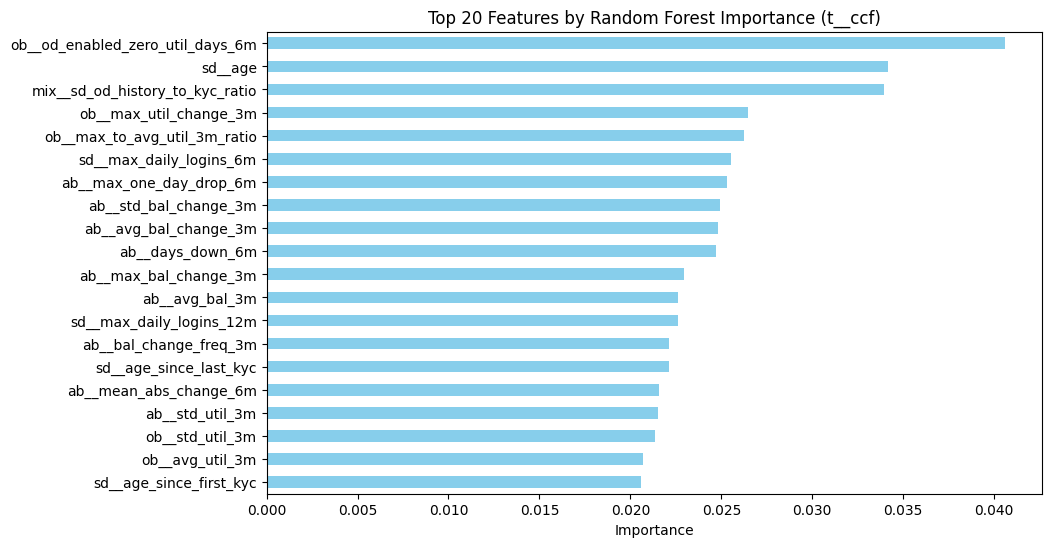

In [35]:
plot_top_features(rf_ccf_imp, 'Top 20 Features by Random Forest Importance (t__ccf)')

In [12]:
# --- 4. Permutation Importance ---
perm_ccf = permutation_importance(rf_ccf, features, target_ccf, n_repeats=10, random_state=42)
perm_ccf_imp = pd.Series(perm_ccf.importances_mean, index=features.columns).sort_values(ascending=False)

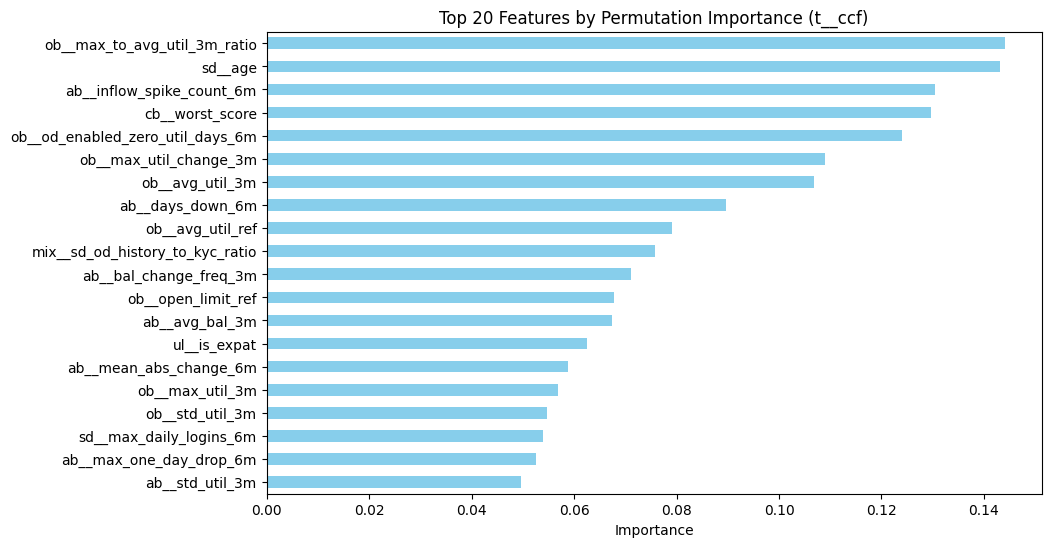

In [13]:
plot_top_features(perm_ccf_imp, 'Top 20 Features by Permutation Importance (t__ccf)')

In [14]:
xgb_ccf = XGBRegressor(random_state=42, n_estimators=1500)
xgb_ccf.fit(features, target_ccf)
xgb_ccf_imp = pd.Series(xgb_ccf.feature_importances_, index=features.columns).sort_values(ascending=False)

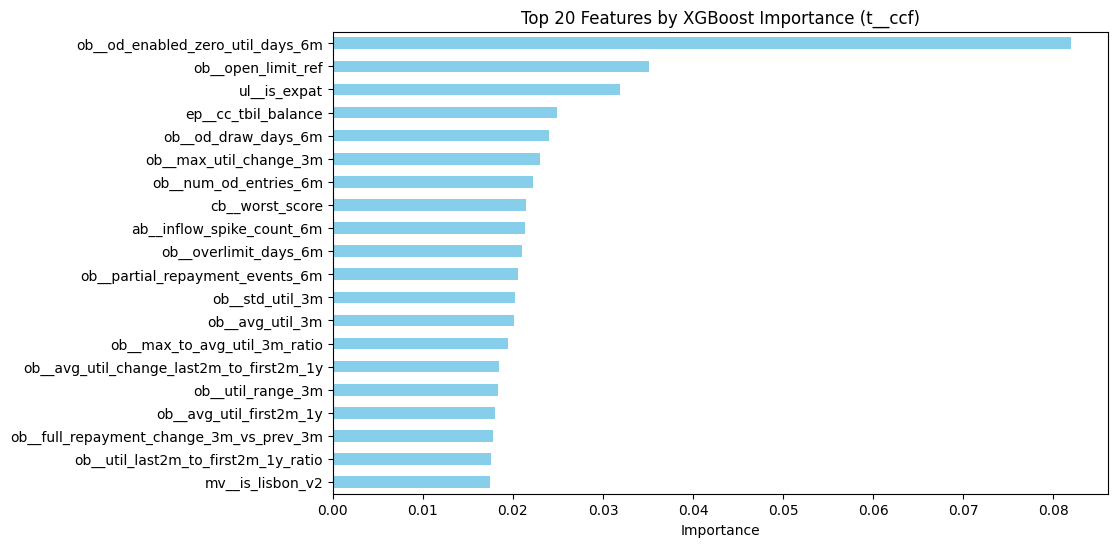

In [15]:
plot_top_features(xgb_ccf_imp, 'Top 20 Features by XGBoost Importance (t__ccf)')

In [20]:
from collections import Counter

def top_features_in_at_least_n(top_lists, n=4):
    all_features = [feat for lst in top_lists for feat in lst]
    counts = Counter(all_features)
    return {feat for feat, c in counts.items() if c >= n}

top_corr_ccf = list(corr_ccf.head(20).index)
top_rf_ccf = list(rf_ccf_imp.head(20).index)
top_perm_ccf = list(perm_ccf_imp.head(20).index)
top_xgb_ccf = list(perm_ccf_imp.head(20).index)

common_ccf_3plus = top_features_in_at_least_n([top_corr_ccf, top_rf_ccf, top_perm_ccf, top_xgb_ccf], n=3)
print("t__ccf features in top 20 of at least 3 metrics:", common_ccf_3plus)


t__ccf features in top 20 of at least 3 metrics: {'ab__days_down_6m', 'sd__age', 'ab__inflow_spike_count_6m', 'ul__is_expat', 'ob__max_util_3m', 'mix__sd_od_history_to_kyc_ratio', 'ob__open_limit_ref', 'ob__od_enabled_zero_util_days_6m', 'ob__max_util_change_3m', 'ab__mean_abs_change_6m', 'ab__max_one_day_drop_6m', 'ab__std_util_3m', 'ob__avg_util_3m', 'ob__std_util_3m', 'ab__avg_bal_3m', 'sd__max_daily_logins_6m', 'ab__bal_change_freq_3m', 'ob__max_to_avg_util_3m_ratio'}


In [ ]:
['ob__avg_util_0_1m', 'ob__limit_ref']

In [ ]:
# --- Top 20 sets for t__ccf ---
top_corr_ccf = set(corr_ccf.head(20).index)
top_rf_ccf = set(rf_ccf_imp.head(20).index)
top_perm_ccf = set(perm_ccf_imp.head(20).index)

# Intersection across all 4 methods
common_ccf = top_corr_ccf & top_mi_ccf & top_rf_ccf & top_perm_ccf
print("Features consistently important for t__ccf:", common_ccf)

In [ ]:
# --- Top 20 sets for t__is_drawn ---
top_corr_is_drawn = set(corr_is_drawn.head(20).index)
top_mi_is_drawn = set(mi_is_drawn.head(20).index)
top_rf_is_drawn = set(rf_is_drawn_imp.head(20).index)
top_perm_is_drawn = set(perm_is_drawn_imp.head(20).index)

# Intersection across all 4 methods
common_is_drawn = top_corr_is_drawn & top_mi_is_drawn & top_rf_is_drawn & top_perm_is_drawn
print("Features consistently important for t__is_drawn:", common_is_drawn)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

target['default_date'] = pd.to_datetime(target['default_date'])
target['eom_default'] = target['default_date'] + pd.offsets.MonthEnd(0)

agg = (
    target
    .groupby('eom_default')
    .agg(
        avg_ccf=('t__ccf', 'mean'),
        n_obs=('t__ccf', 'size')
    )
    .reset_index()
    .sort_values('eom_default')
)

# convert to string for plotting
agg['eom_str'] = agg['eom_default'].dt.to_period('M').astype(str)


In [22]:
agg

,eom_default,avg_ccf,n_obs,eom_str
0,2017-02-28,0.090720,4,2017-02
1,2017-03-31,0.000000,2,2017-03
2,2017-04-30,0.000000,1,2017-04
3,2017-05-31,0.592264,5,2017-05
4,2017-06-30,0.938638,16,2017-06
...,...,...,...,...
100,2025-06-30,0.621374,374,2025-06
101,2025-07-31,0.521774,438,2025-07
102,2025-08-31,0.601968,354,2025-08
103,2025-09-30,0.593454,360,2025-09


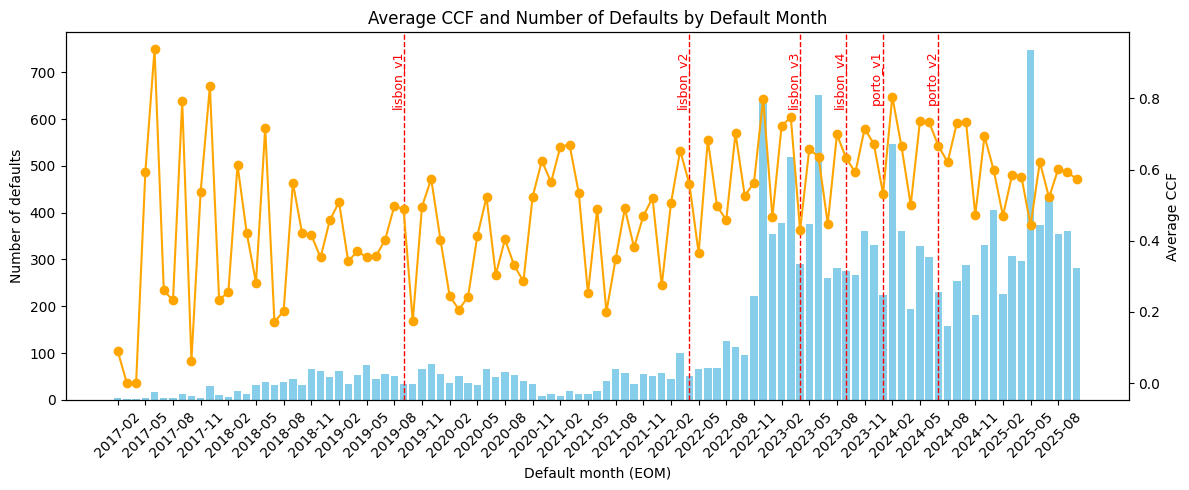

In [23]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np

# Example model periods
version_changes = {
    '2019-09': 'lisbon_v1',
    '2022-04': 'lisbon_v2',
    '2023-04': 'lisbon_v3',
    '2023-09': 'lisbon_v4',
    '2024-01': 'porto_v1',
    '2024-07': 'porto_v2'
}
# Assume agg already prepared
agg['eom_str'] = agg['eom_default'].dt.to_period('M').astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))

# --- bars ---
ax1.bar(agg['eom_str'], agg['n_obs'], color='skyblue')
ax1.set_ylabel('Number of defaults')
ax1.set_xlabel('Default month (EOM)')

# show only every 3rd tick
ticks_to_show = agg['eom_str'].iloc[::3]
ax1.set_xticks(ticks_to_show)
ax1.set_xticklabels(ticks_to_show, rotation=45)

# --- line: avg CCF ---
ax2 = ax1.twinx()
ax2.plot(agg['eom_str'], agg['avg_ccf'], marker='o', color='orange')
ax2.set_ylabel('Average CCF')

# --- add vertical lines and text for version changes ---
for eom, label in version_changes.items():
    if eom in agg['eom_str'].values:
        ax1.axvline(x=eom, color='red', linestyle='--', linewidth=1)
        ax1.text(
            eom, 
            ax1.get_ylim()[1]*0.95,  # slightly below top of y-axis
            label, 
            color='red', 
            rotation=90, 
            va='top', 
            ha='right',
            fontsize=9
        )

plt.title('Average CCF and Number of Defaults by Default Month')
plt.tight_layout()
plt.show()